<h1>Prophet package</h1>

In [21]:
train_df = preprocessed_df.iloc[:-240]
test_df = preprocessed_df.iloc[-240:]

model = Prophet()
for col in preprocessed_df.columns:
    if col in ['ds', 'y']: continue
    model.add_regressor(col)
model.fit(train_df)


16:21:48 - cmdstanpy - INFO - Chain [1] start processing
16:21:57 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
future = test_df.drop(columns=['y'])
forecast = model.predict(future)


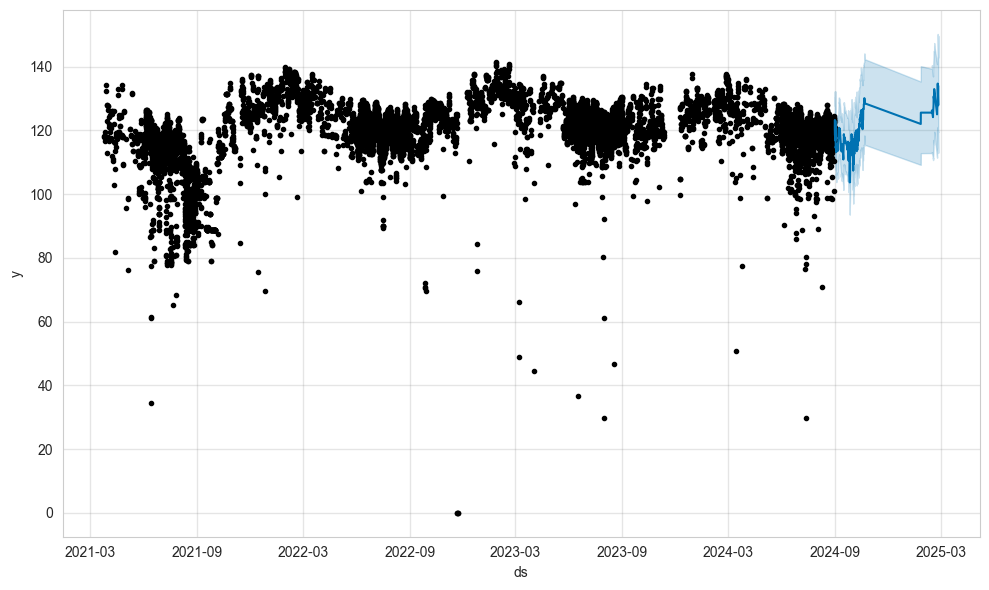

In [23]:
import matplotlib.pyplot as plt

model.plot(forecast)
plt.show()


In [24]:
y_true = test_df['y'].values
y_pred = forecast['yhat'].values

In [26]:
import numpy as np
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_true, y_pred)) / np.mean(y_true) * 100
print(f"Test Error: {rmse:0.2f}%")

Test Error: 10.40%
